# 01 — Does sleep amount/quality/consistency predict HRV and resting heart rate?

**Question:** ignoring exercise entirely for now, does last night's sleep — its
total amount, its deep/REM/light breakdown, its consistency and efficiency —
plus a short (1-2 night) recent history, predict that morning's HRV
(`hrv_rmssd_milli`) and resting heart rate (`resting_heart_rate`)? This
notebook stays at the "what would you intuitively check first" level; longer
lookbacks (3-7 days) and single-isolated-night/skip-day-pairwise variants are
notebook 02's job.

**Reminder on the pairing** (see `src/clean.py`): each row's
`resting_heart_rate` and `hrv_rmssd_milli` come from the sleep at the *end* of
that row's cycle — i.e. the night following that row's `date`, measured on
waking. Concretely: if you wake up Saturday morning, that reading comes from
**Friday night's** sleep, and both live together in the row dated **Friday**
(rows are keyed by "the night that started on this date," not "the day you
woke up"). So:

- The **same-night value** (no lag) = that row's own sleep columns — no
  shifting needed, since the row's sleep and the row's HRV/RHR are already
  the same night.
- **`prior_1d_avg`** = the night *before* that one (Thursday night, in the
  example above) — genuinely two nights removed from the wake-up morning,
  not "last night." `shift(1)` is what skips over the same night.
- **`prior_2d_avg`** = the average of the two nights before that (Thursday +
  Wednesday).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = pd.read_csv("../data/daily.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"{len(df)} days, {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

270 days, 2025-12-19 to 2026-09-14


,cycle_id,date,day_strain,day_avg_hr,day_max_hr,recovery_score,resting_heart_rate,hrv_rmssd_milli,spo2_percentage,skin_temp_celsius,...,hours_rem_sleep,disturbance_count,hours_sleep_debt,hours_needed_baseline,num_workouts,sports,distance_meter_total,zone1_3_minutes,zone4_5_minutes,total_kcal_burned
0,1209987462,2025-12-19,5.891211,64,147,79.0,51.0,81.096750,94.10526,34.542835,...,1.330972,17.0,0.000000,7.911577,0,NaN,0.0,0.000000,0.000000,2021.697419
1,1210683893,2025-12-20,13.061315,74,155,83.0,49.0,83.903230,95.50000,34.208275,...,0.700281,8.0,0.560294,7.911453,1,spin,0.0,42.633667,0.000000,2032.031071
2,1213120705,2025-12-21,11.462260,72,163,82.0,53.0,82.978980,95.95000,34.529667,...,1.767831,17.0,1.164866,7.911330,1,walking,0.0,23.950167,0.266667,1990.981358
3,1214335689,2025-12-22,4.732262,67,119,4.0,61.0,46.241234,89.00000,34.420666,...,0.268367,2.0,1.413727,7.911207,0,NaN,0.0,0.000000,0.000000,1234.770148
4,1215444003,2025-12-22,17.598125,76,194,40.0,49.0,68.771255,94.56250,33.957000,...,1.317000,18.0,2.130000,7.911207,0,NaN,0.0,0.000000,0.000000,2995.576482


## Build the sleep variables

- `total_sleep_hours` — light + deep/slow-wave + REM (all sleep, **not**
  `hours_in_bed`, which also counts time spent awake in bed).
- `deep_sleep_hours` — deep/slow-wave sleep only.
- `rem_sleep_hours` — REM sleep only.
- `restorative_sleep_hours` — deep + REM combined (the two stages most
  associated with physical/nervous-system recovery, as opposed to light
  sleep). Note `restorative_sleep_hours + hours_light_sleep = total_sleep_hours`
  — these four aren't independent, they're a breakdown of the same total.
- `sleep_consistency_pct`, `sleep_efficiency_pct` — WHOOP's own metrics,
  same-night only. They aren't stage-specific, so there's no separate
  deep/REM/restorative version of these.
- For **each** of the four sleep-hours metrics above, also build
  `{metric}_prior_1d_avg` and `{metric}_prior_2d_avg` — see the pairing note
  above for exactly which nights these refer to. Both are shifted so they
  exclude the current night.

In [2]:
df["total_sleep_hours"] = df["hours_light_sleep"] + df["hours_deep_sleep"] + df["hours_rem_sleep"]
df["deep_sleep_hours"] = df["hours_deep_sleep"]
df["rem_sleep_hours"] = df["hours_rem_sleep"]
df["restorative_sleep_hours"] = df["hours_deep_sleep"] + df["hours_rem_sleep"]

sleep_hour_metrics = ["total_sleep_hours", "deep_sleep_hours", "rem_sleep_hours", "restorative_sleep_hours"]

# shift(1) first so the lookback is nights BEFORE the same night, not including it.
# min_periods == window makes each strict: no value until that many full prior nights exist.
lag_vars = []
for metric in sleep_hour_metrics:
    for n in (1, 2):
        col = f"{metric}_prior_{n}d_avg"
        df[col] = df[metric].shift(1).rolling(window=n, min_periods=n).mean()
        lag_vars.append(col)

sleep_vars = sleep_hour_metrics + ["sleep_consistency_pct", "sleep_efficiency_pct"] + lag_vars
outcome_vars = ["hrv_rmssd_milli", "resting_heart_rate"]

print(f"{len(sleep_vars)} sleep variables x {len(outcome_vars)} outcomes = {len(sleep_vars) * len(outcome_vars)} pairs")
df[sleep_vars + outcome_vars].describe()

14 sleep variables x 2 outcomes = 28 pairs


,total_sleep_hours,deep_sleep_hours,rem_sleep_hours,restorative_sleep_hours,sleep_consistency_pct,sleep_efficiency_pct,total_sleep_hours_prior_1d_avg,total_sleep_hours_prior_2d_avg,deep_sleep_hours_prior_1d_avg,deep_sleep_hours_prior_2d_avg,rem_sleep_hours_prior_1d_avg,rem_sleep_hours_prior_2d_avg,restorative_sleep_hours_prior_1d_avg,restorative_sleep_hours_prior_2d_avg,hrv_rmssd_milli,resting_heart_rate
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,269.000000,268.000000,269.000000,268.000000,269.000000,268.000000,269.000000,268.000000,270.000000,270.000000
mean,6.174334,2.019603,1.263786,3.283390,50.337037,89.058847,6.176347,6.177442,2.019331,2.020270,1.261942,1.261570,3.281273,3.281840,65.669080,53.744444
std,1.695332,0.427466,0.518261,0.812614,18.573708,4.872313,1.698169,1.190206,0.428239,0.291091,0.518339,0.365591,0.813383,0.550397,12.533607,3.178323
min,0.935006,0.308617,0.000000,0.308617,5.000000,45.369900,0.935006,2.847458,0.308617,1.138244,0.000000,0.341672,0.308617,1.509094,31.418507,48.000000
25%,5.027383,1.762082,0.916990,2.781159,37.000000,86.709810,5.021072,5.431366,1.760067,1.841542,0.916986,1.025478,2.777058,2.930268,59.361819,52.000000
50%,6.275932,2.009113,1.267022,3.281001,49.500000,89.699390,6.278389,6.172214,2.008981,1.992978,1.258664,1.249214,3.277103,3.305918,66.002340,53.000000
75%,7.357299,2.277108,1.634110,3.850605,65.750000,92.198180,7.360008,6.942091,2.277311,2.207621,1.633733,1.477313,3.844328,3.656033,72.981827,55.000000
max,11.015803,3.176539,2.626261,5.611392,88.000000,98.004520,11.015803,9.821344,3.176539,2.896804,2.626261,2.317483,5.611392,4.869269,131.703100,75.000000


## Correlation matrix

Note: this drops any row missing *any* sleep variable, so `n` here will be
lower than 270 (limited by whichever `prior_2d_avg` column has the least
coverage), while the per-pair table below drops NaNs independently per pair
(so some rows there show a higher `n`). That's why the r values differ
slightly between the two — both are correct, they just use slightly
different row sets.

In [3]:
corr_df = df[sleep_vars + outcome_vars].dropna()
print(f"n = {len(corr_df)} days with complete data")
corr_df.corr(numeric_only=True).loc[sleep_vars, outcome_vars]

n = 268 days with complete data


,hrv_rmssd_milli,resting_heart_rate
total_sleep_hours,-0.009483,-0.098416
deep_sleep_hours,-0.045959,-0.202979
rem_sleep_hours,0.036182,-0.060453
restorative_sleep_hours,-0.001098,-0.145431
sleep_consistency_pct,-0.088985,0.008480
sleep_efficiency_pct,-0.127278,-0.126729
total_sleep_hours_prior_1d_avg,-0.116546,-0.030571
total_sleep_hours_prior_2d_avg,-0.095571,-0.020415
deep_sleep_hours_prior_1d_avg,-0.106892,0.063911
deep_sleep_hours_prior_2d_avg,-0.146088,0.085498


## Correlation + significance for each sleep variable vs each outcome

Pearson r alone doesn't tell you whether a relationship is likely real vs. noise —
the p-value does that (rule of thumb: p < 0.05 means "unlikely to be random chance
given this sample size"). Both matter; report both, not just r.

In [4]:
results = []
for sv in sleep_vars:
    for ov in outcome_vars:
        pair = df[[sv, ov]].dropna()
        r, p = pearsonr(pair[sv], pair[ov])
        results.append({"sleep_var": sv, "outcome": ov, "n": len(pair), "r": round(r, 3), "p_value": round(p, 4)})

results_df = pd.DataFrame(results)
results_df

,sleep_var,outcome,n,r,p_value
0,total_sleep_hours,hrv_rmssd_milli,270,-0.013,0.8254
1,total_sleep_hours,resting_heart_rate,270,-0.092,0.1309
2,deep_sleep_hours,hrv_rmssd_milli,270,-0.053,0.3892
3,deep_sleep_hours,resting_heart_rate,270,-0.194,0.0013
4,rem_sleep_hours,hrv_rmssd_milli,270,0.031,0.6174
5,rem_sleep_hours,resting_heart_rate,270,-0.054,0.3738
6,restorative_sleep_hours,hrv_rmssd_milli,270,-0.008,0.8933
7,restorative_sleep_hours,resting_heart_rate,270,-0.137,0.0244
8,sleep_consistency_pct,hrv_rmssd_milli,270,-0.099,0.1061
9,sleep_consistency_pct,resting_heart_rate,270,0.018,0.7705


## What r and p mean, printed on each panel below

Each panel now prints its own `r=...` and `p=...` directly on the plot, so you
can read accuracy off the graph itself instead of cross-referencing the table
above.

- **r (Pearson correlation, -1 to 1)** - how tightly the points hug the red
  trend line, and in which direction. `r=0` means no linear relationship at
  all (a shapeless cloud); `r=-1` or `r=1` means the points fall in a perfect
  line. Sign is direction: negative means "as x goes up, y tends to go down."
  In this data every r is small (|r| < 0.2), which is *why* the clouds below
  look mostly shapeless even where the red line has a visible slope - r is
  telling you the same thing your eyes are: the line is a real but weak lean,
  not a tight relationship.
- **p (p-value, 0 to 1)** - roughly, "if there were truly *no* relationship,
  how likely is it I'd see an r this large just from random day-to-day noise,
  given how many days I have?" Small p (conventionally < 0.05) means unlikely
  to be pure chance - i.e. probably a real, if possibly small, effect. Large p
  means the r you see is well within what random noise alone could produce -
  don't trust that line's slope.
- **Why both matter together**: r tells you *how strong*, p tells you *how
  believable*. A panel can have a decent-looking r from a handful of extreme
  points (unreliable, high p) or a small-but-real r backed by enough days to
  trust it (low p) - the numbers on each panel let you tell those apart at a
  glance rather than eyeballing the cloud.

## Scatter plots: each sleep variable vs. each outcome

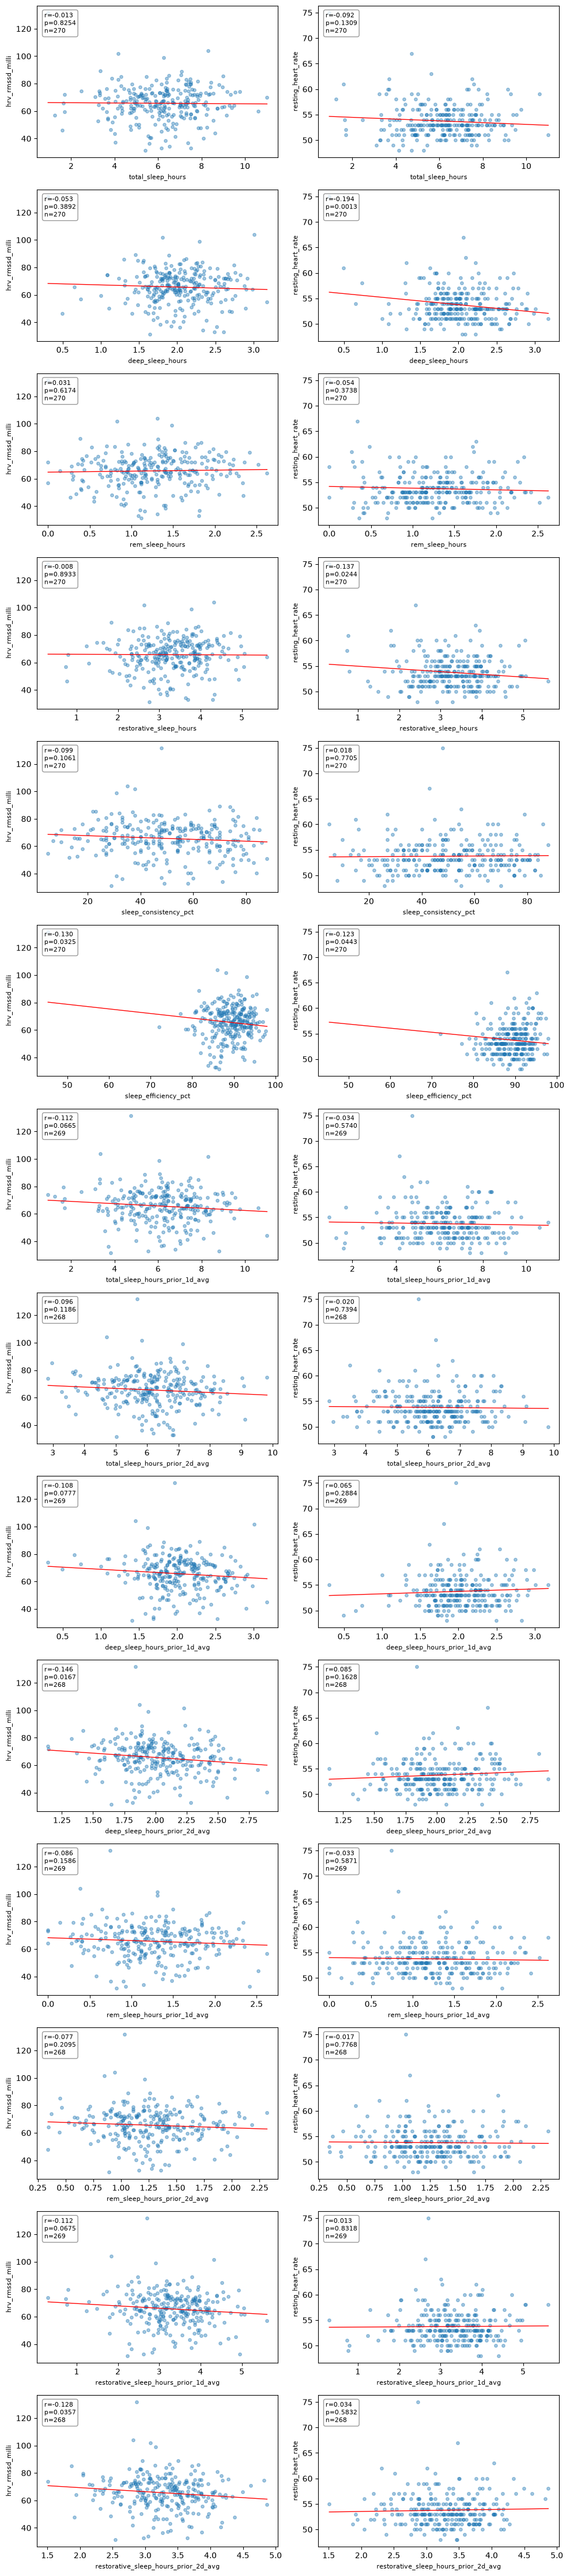

In [5]:
fig, axes = plt.subplots(len(sleep_vars), len(outcome_vars), figsize=(10, 3.2 * len(sleep_vars)))

for i, sv in enumerate(sleep_vars):
    for j, ov in enumerate(outcome_vars):
        ax = axes[i, j]
        pair = df[[sv, ov]].dropna()
        ax.scatter(pair[sv], pair[ov], alpha=0.4, s=15)
        if len(pair) > 1:
            m, b = np.polyfit(pair[sv], pair[ov], 1)
            xs = np.linspace(pair[sv].min(), pair[sv].max(), 50)
            ax.plot(xs, m * xs + b, color="red", linewidth=1)
            r, p = pearsonr(pair[sv], pair[ov])
            ax.text(
                0.03, 0.96, f"r={r:.3f}\np={p:.4f}\nn={len(pair)}",
                transform=ax.transAxes, va="top", ha="left", fontsize=8,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"),
            )
        ax.set_xlabel(sv, fontsize=8)
        ax.set_ylabel(ov, fontsize=8)

plt.tight_layout()
plt.savefig("../output/01_sleep_vs_hrv_rhr_scatter.png", dpi=120)
plt.show()

## Why does higher sleep efficiency associate with *lower* HRV? (r=-0.13)

The RHR direction (higher efficiency -> lower RHR, r=-0.12) matches intuition:
a fragmented, low-efficiency night means more awakenings, and each awakening
spikes heart rate, so more fragmentation should mean a higher measured resting
heart rate. That part checks out.

The HRV direction is the confusing one, and here's the most likely reason it
doesn't behave the same way: **`sleep_efficiency_pct` measures a ratio (time
asleep / time in bed), not an absolute amount of recovery.** A night can be
99% efficient while only being 4 hours long (fell asleep instantly, woke
immediately at 4 hours) - highly "efficient," but with far less deep/REM sleep
than a longer, slightly-more-fragmented 8-hour night sitting at 88% efficiency.
HRV recovery is driven largely by *total* deep and REM sleep accumulated, not
by what fraction of time-in-bed was asleep. So a high efficiency % can
actually be flagging a **short** night (efficient use of a short window)
rather than a **good** one, which would drag HRV down despite the efficiency
number looking great.

**Checked directly**: `sleep_efficiency_pct` vs `total_sleep_hours` in this
data comes back r=-0.237, p=0.0001 - a real, significant negative relationship.
Shorter nights genuinely do tend to score as more "efficient" here. That
supports the explanation above: a high efficiency % is partly just flagging a
short night, not necessarily a well-recovered one, which is consistent with
short-but-efficient nights showing lower HRV despite the high efficiency
number.

## Findings

Ran on 270 days (2025-12-19 to 2026-09-14), 14 sleep variables x 2 outcomes =
28 pairs. 6 of 28 are significant at p<0.05.

- **Same-night `deep_sleep_hours` vs `resting_heart_rate` is the strongest
  relationship in the whole table** (r=-0.194, p=0.0013) — more deep sleep
  that night associates with a lower resting heart rate the same morning.
  This is directionally intuitive (more restorative sleep -> lower RHR) and
  it's specific to the deep-sleep component: `total_sleep_hours` alone has
  no significant RHR relationship (r=-0.092, p=0.13), and neither does
  `rem_sleep_hours` alone (r=-0.054, p=0.37). `restorative_sleep_hours`
  (deep+REM) also reaches significance with RHR (r=-0.137, p=0.024), but
  weaker than deep sleep alone — REM appears to be diluting the deep-sleep
  signal rather than adding to it.
- **HRV doesn't show this same-night deep-sleep effect at all**
  (`deep_sleep_hours` vs HRV: r=-0.053, p=0.39) — the deep-sleep -> lower-RHR
  relationship above is RHR-specific, not a general recovery signal.
- **The short lag history (1-2 nights back) leans the same counter-intuitive
  direction as notebook 01's original 5-day finding, but weaker and mostly
  not significant at this short a window.** Every `_prior_1d_avg` and
  `_prior_2d_avg` variable vs HRV is negative (more recent sleep -> lower
  HRV), and `deep_sleep_hours_prior_2d_avg` reaches significance
  (r=-0.146, p=0.017) — the only lag variable that does at just 1-2 nights.
  This is consistent with the longer-window story in notebook 02 (which
  covers `total_sleep_hours` and `deep_sleep_hours` out to 7 days), where the
  effect only becomes reliably significant once you accumulate 4+ nights of
  history; 1-2 nights alone isn't quite enough signal yet.
- **`sleep_efficiency_pct` remains the only other same-night variable
  significant against both outcomes** (HRV: r=-0.130, p=0.033; RHR:
  r=-0.123, p=0.044), still counter-intuitive in direction. See the note
  above on why (it's partly a proxy for a short night, not a good one).
- **`total_sleep_hours`, `rem_sleep_hours`, `restorative_sleep_hours`, and
  `sleep_consistency_pct` (same-night, no lag) all show no significant
  relationship with either outcome on their own.**
- Takeaway: breaking total sleep into deep/REM/restorative surfaced a real,
  specific, intuitive result — deep sleep and RHR — that was invisible when
  only looking at total sleep hours. The counter-intuitive multi-day HRV
  effect from the original notebook is still visible here at 1-2 days, just
  weaker than at longer windows. REM and restorative sleep haven't yet been
  extended to notebook 02's longer lookback/pairwise treatment — worth doing
  if the deep-sleep-specific RHR result above holds up. Next step for the
  HRV thread is still bringing in training load as a control (see the
  "Future analysis idea" section of the README).
